# Module 5: Analysis of Variance (ANOVA)

This module introduces Analysis of Variance (ANOVA), a powerful statistical method used to compare the means of three or more groups simultaneously.

### Learning Objectives:
- Understand why ANOVA is used instead of multiple t-tests.
- Understand the logic of ANOVA (partitioning variance).
- Perform a One-Way ANOVA.
- Interpret the F-statistic and the ANOVA table.
- Conduct post-hoc tests (e.g., Tukey's HSD) if ANOVA is significant.

In [1]:
# Setup: Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
# statsmodels provides detailed ANOVA tables and post-hoc tests
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

sns.set_style("whitegrid")
np.random.seed(42)
alpha = 0.05
print("Setup Complete")

Setup Complete


## Section 1: ANOVA Fundamentals

Suppose we want to compare the effectiveness of four different fertilizers (Fertilizer 1, 2, 3, and Control) on crop yield.

### 1.1 The Problem with Multiple t-tests

If we have 4 groups, we would need 6 t-tests (1vs2, 1vs3, 1vsC, 2vs3, 2vsC, 3vsC). Running multiple tests increases the probability of making a Type I error (False Positive). This is the **Family-Wise Error Rate (FWER)**.

FWER = $1 - (1-\alpha)^k$, where k is the number of comparisons.

In [2]:
k = 6 # Number of comparisons for 4 groups

family_wise_error_rate = 1 - (1 - alpha)**k
print(f"Family-Wise Error Rate with 6 t-tests at α=0.05: {family_wise_error_rate:.4f} (or {family_wise_error_rate*100:.1f}%)")

# This error rate (26.5%) is much higher than the desired 5%. ANOVA controls this by testing all means simultaneously with a single test (Omnibus test).

Family-Wise Error Rate with 6 t-tests at α=0.05: 0.2649 (or 26.5%)


### 1.2 The Logic of ANOVA

ANOVA (Analysis of Variance) surprisingly tests the difference in means by analyzing variances. It compares the variance *between* groups to the variance *within* groups.

- **Between-Group Variance (MSB - Mean Square Between):** Variation due to the interaction between the samples (the effect of the fertilizer).
- **Within-Group Variance (MSW - Mean Square Within):** Variation due to differences within individual samples (random noise/error).

The **F-statistic** is the ratio: $ F = \frac{MSB}{MSW} $

A large F-statistic indicates that the variation between groups is larger than the variation within groups, suggesting a significant difference in means.

## Section 2: One-Way ANOVA

One-Way ANOVA is used when we have one categorical independent variable (factor) and one continuous dependent variable.

### 2.1 Hypotheses
- H₀: All group means are equal (μ₁ = μ₂ = μ₃ = μ_control).
- H₁: At least one group mean is different.

### 2.2 Data Preparation

Summary Statistics by Group:
            count       mean       std        min        25%        50%  \
Fertilizer                                                                
Control      20.0  49.143507  4.800142  40.433599  46.756392  48.829274   
Fert_1       20.0  50.670124  4.840194  42.201649  46.594842  50.706325   
Fert_2       20.0  59.866548  4.104238  51.184799  57.426452  60.139300   
Fert_3       20.0  49.843017  5.560438  36.901274  47.396697  50.128053   

                  75%        max  
Fertilizer                        
Control     52.540878  57.896064  
Fert_1      52.999309  61.261391  
Fert_2      63.216869  65.285611  
Fert_3      54.074350  57.823218  


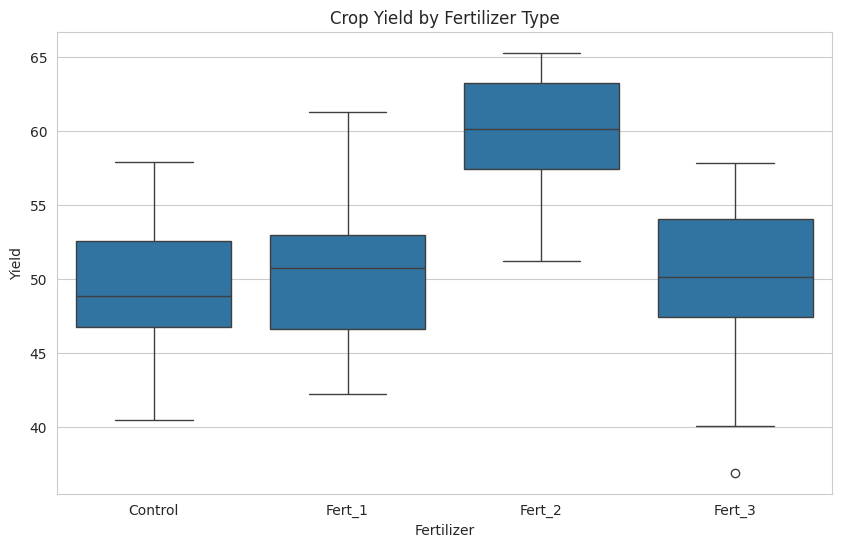

In [3]:
# Simulate data for the 4 fertilizer groups
n_per_group = 20

# Control: Mean=50, Std=5
yield_C = np.random.normal(50, 5, n_per_group)
# Fert 1: Mean=52, Std=5 (Slight improvement)
yield_1 = np.random.normal(52, 5, n_per_group)
# Fert 2: Mean=60, Std=5 (Large improvement)
yield_2 = np.random.normal(60, 5, n_per_group)
# Fert 3: Mean=50, Std=5 (No improvement)
yield_3 = np.random.normal(50, 5, n_per_group)

# Combine into a DataFrame
data = pd.DataFrame({
    'Yield': np.concatenate([yield_C, yield_1, yield_2, yield_3]),
    'Fertilizer': ['Control']*n_per_group + ['Fert_1']*n_per_group + ['Fert_2']*n_per_group + ['Fert_3']*n_per_group
})

print("Summary Statistics by Group:")
print(data.groupby('Fertilizer')['Yield'].describe())

# Visualize the data using Box Plots
plt.figure(figsize=(10, 6))
sns.boxplot(x='Fertilizer', y='Yield', data=data)
plt.title('Crop Yield by Fertilizer Type')
plt.show()

## Section 3: Performing ANOVA and Interpreting the Table

We will use `statsmodels` as it provides a comprehensive ANOVA table, similar to R output.

In [4]:
# Fit the Ordinary Least Squares (OLS) model
# ANOVA can be viewed as a specific form of a linear model.
# The formula 'Yield ~ C(Fertilizer)' means we model Yield based on the Categorical variable Fertilizer.
model = ols('Yield ~ C(Fertilizer)', data=data).fit()

# Generate the ANOVA table
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                    sum_sq    df          F        PR(>F)
C(Fertilizer)  1517.664846   3.0  21.474143  3.565774e-10
Residual       1790.409520  76.0        NaN           NaN


### 3.1 Interpreting the ANOVA Table

- **C(Fertilizer) (Between Groups):**
    - `sum_sq` (SSB): Sum of Squares Between groups. Measures the variation caused by the fertilizer type.
    - `df`: Degrees of freedom (k-1). We have 4 groups (k=4), so df = 3.
    - `F`: The F-statistic (MSB / MSW). (MSB = SSB/df_between, MSW = SSW/df_within).
    - `PR(>F)`: The p-value.
- **Residual (Within Groups/Error):**
    - `sum_sq` (SSW): Sum of Squares Within groups. Measures the random variation (noise).
    - `df`: Degrees of freedom (N-k). Total observations N=80, so df = 80-4 = 76.

### 3.2 Decision
The p-value (`PR(>F)`) is extremely small (much less than α=0.05). Therefore, we **Reject H₀**.

**Conclusion:** There is a statistically significant difference in the mean crop yield among the different fertilizer types.

## Section 4: Post-Hoc Testing (Tukey's HSD)

ANOVA tells us that *at least one* mean is different, but it doesn't tell us *which* ones.

We use Post-Hoc tests (like Tukey's HSD - Honestly Significant Difference) to perform pairwise comparisons while controlling the Family-Wise Error Rate.

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1 group2 meandiff p-adj   lower    upper  reject
------------------------------------------------------
Control Fert_1   1.5266 0.7529  -2.5052  5.5584  False
Control Fert_2   10.723    0.0   6.6913 14.7548   True
Control Fert_3   0.6995 0.9683  -3.3323  4.7313  False
 Fert_1 Fert_2   9.1964    0.0   5.1647 13.2282   True
 Fert_1 Fert_3  -0.8271 0.9492  -4.8589  3.2047  False
 Fert_2 Fert_3 -10.0235    0.0 -14.0553 -5.9918   True
------------------------------------------------------


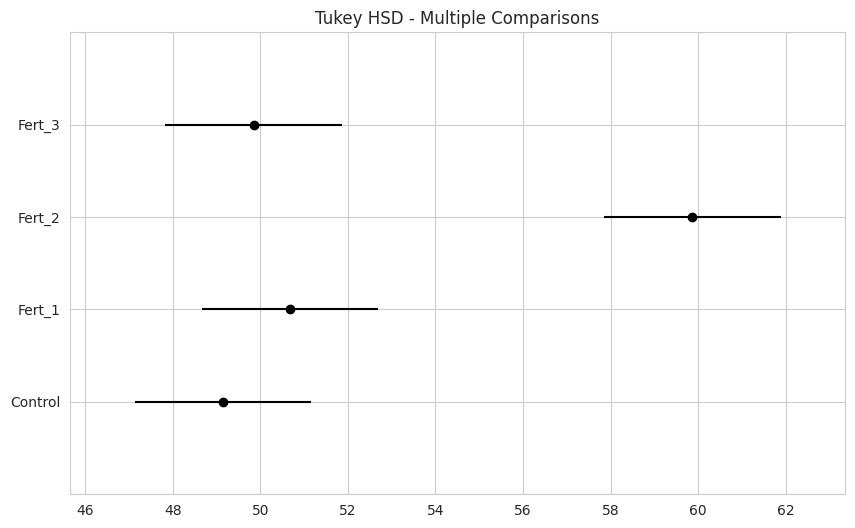

In [5]:
# Perform Tukey's HSD test
tukey_results = pairwise_tukeyhsd(endog=data['Yield'], groups=data['Fertilizer'], alpha=0.05)

print(tukey_results)

# Plot the results
# This plot shows the confidence intervals for the differences between means.
tukey_results.plot_simultaneous()
plt.title('Tukey HSD - Multiple Comparisons')
plt.show()

### Interpreting Tukey's HSD Results

The table shows the comparison between each pair of groups.
- `diff`: The difference between the group means.
- `lower`, `upper`: The 95% confidence interval for the difference.
- `reject`: True if the difference is statistically significant (p < 0.05).

**Key Insight:** If the confidence interval (`lower` to `upper`) does NOT cross zero, the difference is significant.

Based on the results (look at the `reject` column):
- Fert_2 is significantly different from Control, Fert_1, and Fert_3.
- Control, Fert_1, and Fert_3 are not significantly different from each other.

**Final Conclusion:** Fertilizer 2 leads to a significantly higher crop yield compared to the other options.